# Homework 4 General comment
In HW #4 we'll ask you to produce a little bit more code than in previous exercise sets. This will require you to check the outputs more carefully, too. Feel free to use the many examples we've done in class.

# Exercise 1: Transformer Classifier for Kinematics (30 points)

Suppose a ball is launched from the origin with some initial velocity. You observe 10 noisy position measurements $(x, y)$ during the first half of the flight.

Your task is to predict whether the ball will land to the left ($x < 0$) or to the right ($x > 0$) of the origin.

Before you start, review these items (no need to write the answer):
- What do the Q, K, V projections do?
- What does `nn.TransformerEncoderLayer` contain in terms of parameters and structure?
- Why does positional encoding matter for ordered sequences?

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cpu")  # this problem is tiny, CPU is fine
print("Ready!")

Ready!


## Generate the data

Each trajectory follows projectile motion:

$$x(t) = v_{x0}\, t, \qquad y(t) = v_{y0}\, t - \tfrac{1}{2}g\,t^2$$

We add Gaussian noise to simulate measurement uncertainty.
The label is 1 if the ball lands at $x > 0$ (right) or 0 if $x < 0$ (left).


In [2]:
G = 9.8           # gravity
N_STEPS = 10      # measurements per trajectory
NOISE = 0.3       # measurement noise (meters)

def make_trajectory():
    """Generate one noisy trajectory and a left/right label."""
    vx = np.random.uniform(-5, 5)      # horizontal velocity
    vy = np.random.uniform(5, 15)      # upward velocity
    t_flight = 2 * vy / G              # total flight time

    # Observe only the FIRST HALF of the flight
    t = np.linspace(0, t_flight * 0.5, N_STEPS)
    x = vx * t + np.random.normal(0, NOISE, N_STEPS)
    y = vy * t - 0.5 * G * t**2 + np.random.normal(0, NOISE, N_STEPS)

    # Where does it actually land?
    x_land = vx * t_flight
    label = 1 if x_land > 0 else 0     # 1=right, 0=left

    # Each time step is one transformer token: (x, y)
    sequence = np.stack([x, y], axis=1).astype(np.float32)
    return sequence, label, x_land


def make_dataset(n):
    """Generate n trajectories, return as tensors."""
    seqs, labels = [], []
    for _ in range(n):
        s, l, _ = make_trajectory()
        seqs.append(s)
        labels.append(l)
    return torch.tensor(np.array(seqs)), torch.tensor(labels)

X_train, y_train = make_dataset(4000)
X_val, y_val     = make_dataset(1000)

print(f"X_train shape: {X_train.shape}  -- (samples, time_steps, features)")
print(f"y_train shape: {y_train.shape}  -- (samples,)")
print(f"\nEach sample: {N_STEPS} time steps, each with 2 features (x, y)")
print(f"Labels: 0=left, 1=right")
print(f"Class balance: left={int((y_train==0).sum())}, right={int((y_train==1).sum())}")

X_train shape: torch.Size([4000, 10, 2])  -- (samples, time_steps, features)
y_train shape: torch.Size([4000])  -- (samples,)

Each sample: 10 time steps, each with 2 features (x, y)
Labels: 0=left, 1=right
Class balance: left=1925, right=2075


### Visualize the trajectories

This should give you some idea of the data you will be using. You can see that the first step in the trajectory may be to the left even though the ball eventually ends up to the right.

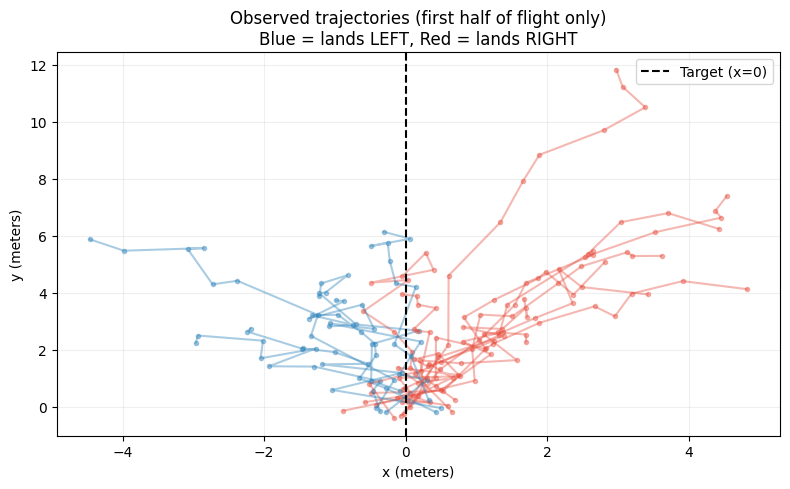

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(20):
    seq, label, x_land = make_trajectory()
    color = "#2980b9" if label == 0 else "#e74c3c"
    ax.plot(seq[:, 0], seq[:, 1], "o-", color=color, alpha=0.4, markersize=3)

ax.axvline(0, color="k", ls="--", label="Target (x=0)")
ax.set_xlabel("x (meters)"); ax.set_ylabel("y (meters)")
ax.set_title("Observed trajectories (first half of flight only)\n"
             "Blue = lands LEFT, Red = lands RIGHT")
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# part 1(a): Build the Transformer Model (10 points)

Write your own code to complete the `TrajectoryClassifier` class below.

Your model should include the following two functions:

`__init__` -- define these layers:
- `self.embed`: an `nn.Linear` that projects each $(x, y)$ pair (2 features) up to `d_model` dimensions
- `self.pos`: a learnable positional encoding: `nn.Parameter(torch.randn(1, N_STEPS, d_model) * 0.1)`
- `self.transformer`: a `nn.TransformerEncoder` built from `nn.TransformerEncoderLayer`. Use `batch_first=True` and `dim_feedforward=64`
- `self.classifier`: an `nn.Linear` that maps from `d_model` to `n_classes`

`forward(self, x)` where `x` has shape `(batch, 10, 2)`:
- Embed: `x = self.embed(x)` to make the shape `(batch, 10, d_model)`
- Add positional encoding: `x = x + self.pos`
- Transformer: `x = self.transformer(x)`
- Average pool over time: `x = x.mean(dim=1)` to make the shape `(batch, d_model)`
- Classify: `return self.classifier(x)`

In [24]:
class TrajectoryClassifier(nn.Module):

    def __init__(self, input_dim=2, d_model=32, n_heads=2, n_layers=2, n_classes=2):
        super().__init__()

        # YOUR CODE HERE (about 6 lines)
        # Define: self.embed, self.pos, self.transformer, self.classifier
        self.embed = nn.Linear(input_dim, d_model)
        self.pos = nn.Parameter(torch.randn(1, N_STEPS, d_model) * 0.1)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=64, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.classifier = nn.Linear(d_model, n_classes)


    def forward(self, x):
        """x: (batch, 10, 2) -- sequence of (x, y) measurements"""

        # YOUR CODE HERE (about 5 lines)
        # Steps: embed -> add pos -> transformer -> mean pool -> classify
        x = self.embed(x)
        x = x + self.pos
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)

### Unit tests

You can run this cell to check your code.
- Is `forward()` complete?
- Does the output have the correct shape?

In [25]:
# -- Sanity checks (do not modify) --
try:
    _test_model = TrajectoryClassifier()
    _test_input = torch.randn(4, N_STEPS, 2)
    _test_output = _test_model(_test_input)

    assert _test_output is not None, "forward() returned None -- did you forget the return statement?"
    assert _test_output.shape == (4, 2), f"Expected shape (4, 2), got {_test_output.shape}"

    _n = sum(p.numel() for p in _test_model.parameters())
    print(f"Output shape: {_test_output.shape}  [correct]")
    print(f"Parameters:   {_n:,}")
    print("\nAll checks passed!")

except Exception as e:
    print(f"ERROR: {e}")
    print("\nGo back and check your model.")

Output shape: torch.Size([4, 2])  [correct]
Parameters:   17,570

All checks passed!


## part 1(b): Write the Training Loop (10 points)

Write a training loop that:
1. Creates a `TrajectoryClassifier` and stores it in a variable called `model`
2. Creates an `Adam` optimizer with learning rate `1e-3`
3. Creates a cross-entropy loss function (`nn.CrossEntropyLoss()`)
4. Trains for 30 epochs. In each epoch:
   - Set the model to training mode (`model.train()`)
   - Zero the gradients
   - Compute logits by passing `X_train` through the model
   - Compute the loss between logits and `y_train`
   - Backpropagate and update weights
   - Set the model to eval mode (`model.eval()`) and compute validation accuracy in the usual way:
     ```python
     with torch.no_grad():
         val_logits = model(X_val)
         val_acc = (val_logits.argmax(dim=1) == y_val).float().mean().item()
     ```
5. Store the training loss in a list called `train_losses` and the validation accuracy in a list called `val_accs`
6. Print the loss and accuracy every 5 epochs

These two lists (`train_losses` and `val_accs`) are used by later cells,
so make sure you name them correctly.


In [17]:
# Create: model, optimizer, criterion
# Lists:  train_losses = [], val_accs = []
# Loop:   30 epochs of training + validation
# Print:  every 5 epochs
#
# Expected output: validation accuracy should reach ~85-95%

# YOUR CODE HERE

model = TrajectoryClassifier().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_accs = []

for epoch in range(30):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train.to(DEVICE))
    loss = criterion(logits, y_train.to(DEVICE))
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val.to(DEVICE))
        val_acc = (val_logits.argmax(dim=1) == y_val.to(DEVICE)).float().mean().item()
    val_accs.append(val_acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1:2d}/30 | Train Loss: {loss.item():.4f} | Val Accuracy: {val_acc:.4f}") # <-- remove this line after you've written your code

Epoch  5/30 | Train Loss: 0.5405 | Val Accuracy: 0.9770
Epoch 10/30 | Train Loss: 0.3030 | Val Accuracy: 0.9730
Epoch 15/30 | Train Loss: 0.1677 | Val Accuracy: 0.9690
Epoch 20/30 | Train Loss: 0.0964 | Val Accuracy: 0.9860
Epoch 25/30 | Train Loss: 0.0645 | Val Accuracy: 0.9790
Epoch 30/30 | Train Loss: 0.0501 | Val Accuracy: 0.9830


## part 1(c): Plot the Training Curves (10 points)

Plot the following training curves:
- training loss vs. epoch (use your `train_losses` list)
- validation accuracy (%) vs. epoch (use your `val_accs` list). Draw a dashed horizontal line at 50% to show random chance.

Dont' forget to label the axes, add some titles, and add a legend to the validation accuracy plot.

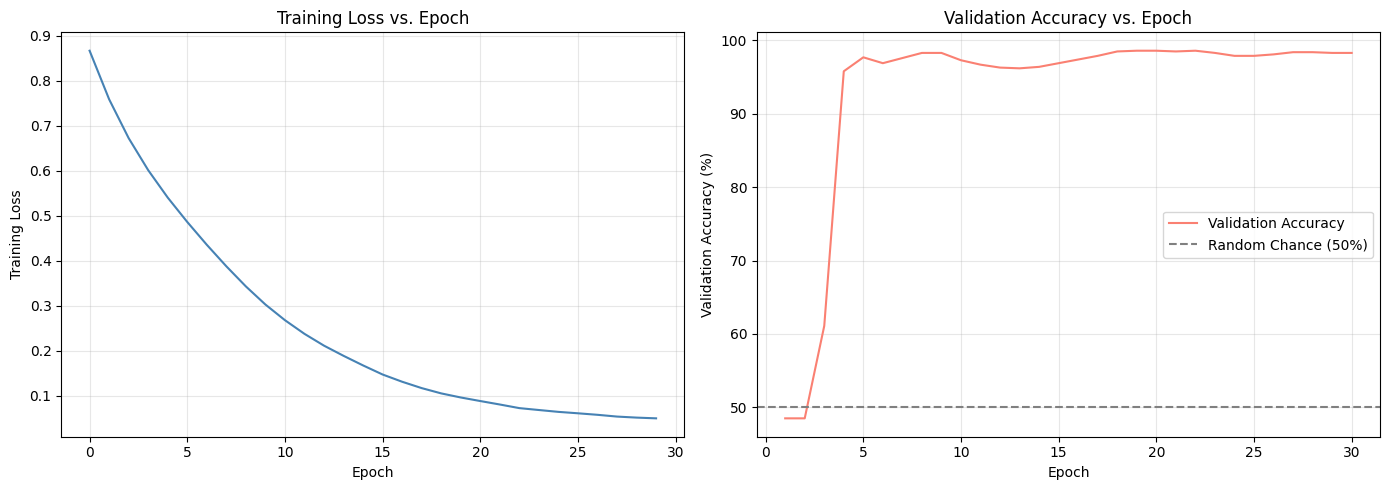

In [18]:
# Plot these two training curves:
# - training loss vs epoch
# - validation accuracy (%) vs epoch, with a 50% baseline

# YOUR CODE HERE

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot training loss
ax1.plot(train_losses, color='steelblue', label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss vs. Epoch')
ax1.grid(True, alpha=0.3)

# Plot validation accuracy
epochs = range(1, len(val_accs) + 1)
ax2.plot(epochs, [acc * 100 for acc in val_accs], color='salmon', label='Validation Accuracy')
ax2.axhline(50, color='gray', linestyle='--', label='Random Chance (50%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy (%)')
ax2.set_title('Validation Accuracy vs. Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()  # <-- remove this line after you've written your code

# Exercise 2: autoencoder for anomaly detection  (40 points)

In this exercise you will train a nonlinear autoencoder and use it for anomaly detection. The idea is straightforward: train the autoencoder only on "normal" stars in a SDSS stellar photometry dataset.

When you then feed the autoencoder an unusual star, it reconstructs it poorly because it has no compact code for that type of object.
The reconstruction error $\|x - \hat{x}\|^2$ therefore serves as an anomaly score. High values of anomaly score indicate an outlier with respect to the training data.

There are three specific parts where you will need to write code to complete the exercise.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

## Load dataset

The SDSS dataset is in the file `sspp_colors.npz`. You can put it in the same directory as this notebook. (In Colab, click on the Folder icon at left to upload it.)

For each star we have
- colors: photometric strength in u-g, g-r, r-i, and i-z wavelength bands
- $T_\text{eff}$: effective temperature [K]
- $\log g$: base-10 logarithm of the surface gravity
- Fe/H: iron abundance of the star relative to the Sun


In [20]:
npz = np.load('sspp_colors.npz')
colors       = npz['colors'].astype(np.float32)
Teff         = npz['Teff'].astype(np.float32)
logg         = npz['logg'].astype(np.float32)
FeH          = npz['FeH'].astype(np.float32)

print(f'Total stars: {len(colors):,}')
print(f'Teff:   {Teff.min():.0f} - {Teff.max():.0f} K')
print(f'logg:   {logg.min():.2f} - {logg.max():.2f}')
print(f'[Fe/H]: {FeH.min():.2f} - {FeH.max():.2f}')

Total stars: 296,256
Teff:   4500 - 8000 K
logg:   1.00 - 4.97
[Fe/H]: -4.49 - 0.75


Now we assign labels to define which stars are "normal" and which are anomalies. These labels are derived from spectroscopy, and the autoencoder will never see them during training. We use them only to construct the training set and to evaluate the anomaly detector afterwards. (These labels are kind of the "solutions" to the problem.)

- Normal: main-sequence FGK dwarfs, $4500 \leq T_\text{eff} \leq 7000$ K and $\log g \geq 3.5$
- Giants: evolved stars with $\log g < 3.0$ and $T_\text{eff} < 5500$ K
- Metal-poor: ancient halo stars with [Fe/H] $< -1.5$

It is useful to notice that the normal and giants have similar values for $T_\text{eff}$. This will be important later.

In [21]:
normal_mask    = (Teff >= 4500) & (Teff <= 7000) & (logg >= 3.5)
giant_mask     = (logg < 3.0) & (Teff < 5500)
metalpoor_mask = (FeH < -1.5)
anomaly_mask   = giant_mask | metalpoor_mask
normal_mask    = normal_mask & ~anomaly_mask   # remove any overlap

print(f'Normal (main-sequence FGK): {normal_mask.sum():,}')
print(f'Giants:                     {giant_mask.sum():,}')
print(f'Metal-poor:                 {metalpoor_mask.sum():,}')

Normal (main-sequence FGK): 196,767
Giants:                     17,779
Metal-poor:                 65,263


You should see 196,767 normal stars, along with 17,779 giants and 65,263 metal-poor stars.

### Create DataLoaders and visualize data

We fit the `StandardScaler` on normal training stars only. Fitting on the full dataset would allow information about the anomaly distribution to leak into the preprocessing.

In [27]:
X_normal  = colors[normal_mask]
X_giants  = colors[giant_mask]
X_metpoor = colors[metalpoor_mask]

scaler = StandardScaler()
X_normal_scaled  = scaler.fit_transform(X_normal)
X_giants_scaled  = scaler.transform(X_giants)
X_metpoor_scaled = scaler.transform(X_metpoor)

N       = len(X_normal_scaled)
n_train = int(0.8 * N)
perm    = np.random.permutation(N)
X_train = X_normal_scaled[perm[:n_train]]
X_test  = X_normal_scaled[perm[n_train:]]

print(f'Training (normal):  {len(X_train):,}')
print(f'Test (normal):      {len(X_test):,}')
print(f'Giants:             {len(X_giants_scaled):,}')
print(f'Metal-poor:         {len(X_metpoor_scaled):,}')

Training (normal):  157,413
Test (normal):      39,354
Giants:             17,779
Metal-poor:         65,263


Stars are often plotted in a diagram called the Hertzsprung-Russell diagram that groups them into classes based on $T_\text{eff}$ and $\log g$.

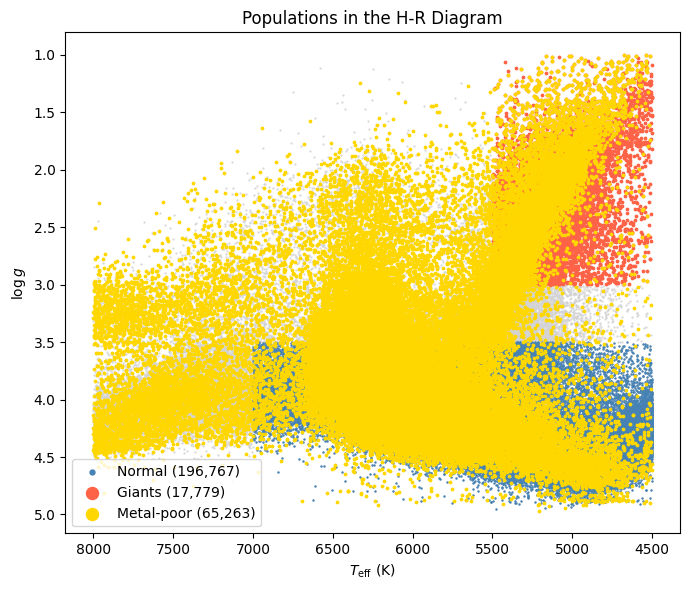

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(Teff, logg, s=0.3, color='lightgray')
ax.scatter(Teff[normal_mask],    logg[normal_mask],
           s=0.5, color='steelblue',
           label=f'Normal ({normal_mask.sum():,})')
ax.scatter(Teff[giant_mask],     logg[giant_mask],
           s=3, color='tomato',
           label=f'Giants ({giant_mask.sum():,})')
ax.scatter(Teff[metalpoor_mask], logg[metalpoor_mask],
           s=3, color='gold',
           label=f'Metal-poor ({metalpoor_mask.sum():,})')
ax.set_xlabel(r'$T_{\mathrm{eff}}$ (K)')
ax.set_ylabel(r'$\log g$')
ax.set_title('Populations in the H-R Diagram')
ax.invert_xaxis()
ax.invert_yaxis()
ax.legend(markerscale=5, loc='lower left')
plt.tight_layout()
plt.show()

*Prediction time!*

Look at the H-R diagram above. The autoencoder will be trained only on the blue points and will never see the physical labels. Its only input is the four photometric color strengths u-g, g-r, r-i, i-z.

Which anomaly type do you expect the autoencoder to detect more easily — red giants or metal-poor halo stars? Justify your prediction in physical terms. Think about what separates each population from normal stars in color space, and about what broadband photometry can and cannot distinguish.

You don't have to write down your answer yet, but keep it in mind for part 2(d).

Now let's get to work.


## part 2(a): autoencoder architecture (10 points)

Complete the autoencoder architecture by completing the encoder and decoder `nn.Sequential` stacks below using `nn.Linear` and `nn.ReLU` layers.

Two things to keep in mind:
- ReLU always goes between linear layers, not after the final one in each stack
- The decoder output layer must have no activation function, because the reconstruction is a real-valued vector that should not be transformed or "logicalized."

A correct implementation has 470 trainable parameters. The check at the bottom of the cell will confirm this.

```
Encoder:  4  ->  16  ->  8  ->  2     (ReLU after each hidden layer)
Decoder:  2  ->  8   ->  16 ->  4     (ReLU after each hidden layer, no activation on output)
```

In [29]:
class NonlinearAutoencoder(nn.Module):
    def __init__(self, input_dim=4, latent_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            # YOUR CODE HERE
            # input_dim -> 16 -> 8 -> latent_dim, ReLU after first two layers
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, latent_dim)
        )

        self.decoder = nn.Sequential(
            # YOUR CODE HERE
            # latent_dim -> 8 -> 16 -> input_dim, ReLU after first two layers, no final activation
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)


model    = NonlinearAutoencoder(input_dim=4, latent_dim=2)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {n_params}')  # Expected: 470

NonlinearAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=4, bias=True)
  )
)

Total trainable parameters: 470


## part 2(b): write training loop (10 points)

The `DataLoader`, loss function, and optimizer are set up below. Fill in the five standard steps of a PyTorch training iteration inside the batch loop. You may want to look back to examples from class.

Recall that the autoencoder is an unsupervised model: the goals is to get the reconstructed output to match the input. The input is the target!

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_loader   = DataLoader(
    TensorDataset(X_train_tensor, X_train_tensor),
    batch_size=512, shuffle=True
)

criterion    = nn.MSELoss()
optimizer    = optim.Adam(model.parameters(), lr=0.001)
loss_history = []

model.train()
# You can change the number of epochs if you like, but this works.
for epoch in range(150):
    epoch_loss = 0.0
    for x_batch, target_batch in train_loader:
        # YOUR CODE HERE
        # 1. Zero the gradients
        # 2. Forward pass
        # 3. Compute loss
        # 4. Backward pass
        # 5. Update weights
        pass
        epoch_loss += loss.item() * len(x_batch)

    epoch_loss /= len(X_train)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 25 == 0:
        print(f'Epoch {epoch+1:4d}/150  |  Loss: {epoch_loss:.6f}')

In [ ]:
# Run this to plot the training loss curve as function of epoch
# You have written this code many times already.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color='steelblue', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Nonlinear Autoencoder Training Loss')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## part 2(c): anomaly detection (10 points)

To define the anomaly score, we need to write a function called `reconstruction_error(model, X)` that:
- Converts `X` (numpy array, shape `(N, 4)`) to a PyTorch tensor
- Passes it through the model in evaluation mode using `torch.no_grad()`
- Returns a numpy array of shape `(N,)` with the per-sample squared error $\|x_i - \hat{x}_i\|^2 = \sum_{j=1}^4 (x_{ij} - \hat{x}_{ij})^2$

Compute and print the mean and standard deviation for the normal test set, the giants, and the metal-poor stars.

In [ ]:
def reconstruction_error(model, X):
    """
    Parameters
    ----------
    model : NonlinearAutoencoder
    X     : np.ndarray, shape (N, 4)

    Returns
    -------
    errors : np.ndarray, shape (N,)
    """
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        X_hat = model(X_tensor).numpy()
    return np.sum((X - X_hat) ** 2, axis=1)


err_normal  = reconstruction_error(model, X_test)
err_giants  = reconstruction_error(model, X_giants_scaled)
err_metpoor = reconstruction_error(model, X_metpoor_scaled)

print('Mean reconstruction error +/- std:')
print(f'  Normal:      {err_normal.mean():.5f} +/- {err_normal.std():.5f}')
print(f'  Giants:      {err_giants.mean():.5f} +/- {err_giants.std():.5f}')
print(f'  Metal-poor:  {err_metpoor.mean():.5f} +/- {err_metpoor.std():.5f}')

Now you can plot the anomaly score distributions for each class with the provided code. The normal stars cannot be anomalous because they were the training data!

In [ ]:
all_errors = np.concatenate([err_normal, err_giants, err_metpoor])
xmax = np.percentile(all_errors, 99)
bins = np.linspace(0, xmax, 80)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, yscale in zip(axes, ['linear', 'log']):
    ax.hist(err_normal,  bins=bins, density=True, alpha=0.5,
            color='steelblue', label='Normal (test)')
    ax.hist(err_giants,  bins=bins, density=True, alpha=0.5,
            color='tomato',    label='Giants')
    ax.hist(err_metpoor, bins=bins, density=True, alpha=0.5,
            color='gold',      label='Metal-poor')
    ax.set_xlabel(r'Reconstruction error $\|x - \hat{x}\|^2$')
    ax.set_ylabel('Density')
    ax.set_yscale(yscale)
    ax.set_title(f'Anomaly Score Distribution ({yscale} scale)')
    ax.legend()

plt.tight_layout()
plt.show()

We might identify anomalous stars (not normal stars) with reconstruction error scores near 1. If we make that the "target" purely for the purposes of comparison, then we can plot a ROC curve and calculate AUC.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for err_anom, label, color in [
        (err_giants,  'Giants',     'tomato'),
        (err_metpoor, 'Metal-poor', 'goldenrod')]:

    scores = np.concatenate([err_normal, err_anom])
    y_true = np.concatenate([np.zeros(len(err_normal)), np.ones(len(err_anom))])
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{label}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: Autoencoder Anomaly Detection')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## part 2(d): comparison (5 points)

Return to your prediction from the beginning of this exercise: "which anomaly type will the autoencoder detect more easily?" Was your prediction correct?

Now, after looking at the ROC curves, answer again: which anomaly type — giants or metal-poor stars — is more easily detected? Give a physical explanation of the result. (*Hint*: a red giant and a cool main-sequence dwarf are at the same $T_\text{eff}$ — how different do they look in u-g, g-r, r-i, i-z?)


## part 2(e): performance of non-linear vs. linear autoencoders (5 points)

What if you replaced the nonlinear autoencoder above with a linear autoencoder, keeping everything else the same?
Would you expect the anomaly detection AUC to be higher, lower, or similar?
Justify your answer by connecting to the mathematical properties of the two models (and perhaps to PCA).


# Exercise 3: Restricted Boltzmann Machines (30 points)

A Restricted Boltzmann Machine with visible units $\mathbf{v} = \{v_i\}$ and hidden units $\mathbf{h} = \{h_j\}$ is defined by the energy function

$$E(\mathbf{v}, \mathbf{h}) = - \sum_i a_i v_i - \sum_j b_j h_j - \sum_{i,j} v_i W_{ij} h_j$$

where $a_i$ and $b_j$ are biases and $W_{ij}$ are the weights.

## part 3(a): Joint probabilities (10 points)

Write down the joint probability $P(\mathbf{v}, \mathbf{h})$ in terms of $E(\mathbf{v}, \mathbf{h})$ and identify the physical quantity that plays the role of the partition function $Z$.

## part 3(b): gradients for RBM (10 points)

The log-likelihood gradient for the RBM with respect to a weight $W_{ij}$ is
$$\frac{\partial}{\partial W_{ij}} \log P(\mathbf{v}_{(\text{data})}) = \langle v_i h_j \rangle_{\text{data}} - \langle v_i h_j \rangle_{\text{model}}$$
where the first expectation is over the data distribution (with $\mathbf{h}$ sampled given $\mathbf{v}^{(\text{data})}$) and the second is over the full model distribution.

Why is the second term $\langle v_i h_j \rangle_{\text{model}}$ computationally intractable to evaluate exactly for a large RBM? (*Hint*: think about what summing over all configurations entails.)

## part 3(c): features in RBM (10 points)

After training an RBM on a dataset of images (e.g., handwritten digits), each hidden unit $h_j$ has an associated weight vector $W_{:j} = \{W_{ij}\}$ over all visible pixels.

The quantity $P(h_j = 1 | \mathbf{v})$ is exactly equal to $\sigma\left(b_j + \sum_i W_{ij} v_i\right)$, where $\sigma$ is the logistic sigmoid. Interpret this equality: what is $h_j$ "detecting" in the visible input $\mathbf{v}$?


# Task
Implement the `__init__` and `forward` methods of the `TrajectoryClassifier` class according to the problem description, ensuring that `self.embed` is an `nn.Linear` layer, `self.pos` is a learnable positional encoding `nn.Parameter`, `self.transformer` is an `nn.TransformerEncoder` built from `nn.TransformerEncoderLayer` with `batch_first=True` and `dim_feedforward=64`, and `self.classifier` is an `nn.Linear` layer. The `forward` method should apply these components in sequence: embedding, positional encoding, transformer, mean pooling, and classification. Finally, run the unit test cell `Dl0RrAyRlYkD` to verify the implementation.

## Implement TrajectoryClassifier __init__

### Subtask:
Define the `__init__` method of the `TrajectoryClassifier` class. This includes initializing `self.embed` (an `nn.Linear` layer), `self.pos` (a learnable positional encoding `nn.Parameter`), `self.transformer` (an `nn.TransformerEncoder`), and `self.classifier` (an `nn.Linear` layer) according to the problem description.


**Reasoning**:
The subtask requires defining the `__init__` method of the `TrajectoryClassifier` class by initializing `self.embed`, `self.pos`, `self.transformer`, and `self.classifier` as specified in the instructions. This involves creating `nn.Linear` layers, an `nn.Parameter` for positional encoding, and configuring an `nn.TransformerEncoder` with `nn.TransformerEncoderLayer`.



In [4]:
class TrajectoryClassifier(nn.Module):

    def __init__(self, input_dim=2, d_model=32, n_heads=2, n_layers=2, n_classes=2):
        super().__init__()

        # YOUR CODE HERE (about 6 lines)
        # Define: self.embed, self.pos, self.transformer, self.classifier
        self.embed = nn.Linear(input_dim, d_model)
        self.pos = nn.Parameter(torch.randn(1, N_STEPS, d_model) * 0.1)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=64, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.classifier = nn.Linear(d_model, n_classes)


    def forward(self, x):
        """x: (batch, 10, 2) -- sequence of (x, y) measurements"""

        # YOUR CODE HERE (about 5 lines)
        # Steps: embed -> add pos -> transformer -> mean pool -> classify

        pass  # <-- remove this line after you've written your code

**Reasoning**:
The next step is to implement the `forward` method of the `TrajectoryClassifier` class by applying the `embed`, `pos` (positional encoding), `transformer`, mean pooling, and `classifier` layers in sequence, as described in the problem statement. I also need to remove the `pass` statement.



In [5]:
class TrajectoryClassifier(nn.Module):

    def __init__(self, input_dim=2, d_model=32, n_heads=2, n_layers=2, n_classes=2):
        super().__init__()

        # YOUR CODE HERE (about 6 lines)
        # Define: self.embed, self.pos, self.transformer, self.classifier
        self.embed = nn.Linear(input_dim, d_model)
        self.pos = nn.Parameter(torch.randn(1, N_STEPS, d_model) * 0.1)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=64, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.classifier = nn.Linear(d_model, n_classes)


    def forward(self, x):
        """x: (batch, 10, 2) -- sequence of (x, y) measurements"""

        # YOUR CODE HERE (about 5 lines)
        # Steps: embed -> add pos -> transformer -> mean pool -> classify
        x = self.embed(x)
        x = x + self.pos
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)

**Reasoning**:
The `forward` method of the `TrajectoryClassifier` class has been implemented as specified in the problem description, applying embedding, positional encoding, transformer, mean pooling, and classification layers in sequence. Now, the subtask requires running the unit test cell `Dl0RrAyRlYkD` to verify the implementation.



In [6]:
# -- Sanity checks (do not modify) --
try:
    _test_model = TrajectoryClassifier()
    _test_input = torch.randn(4, N_STEPS, 2)
    _test_output = _test_model(_test_input)

    assert _test_output is not None, "forward() returned None -- did you forget the return statement?"
    assert _test_output.shape == (4, 2), f"Expected shape (4, 2), got {_test_output.shape}"

    _n = sum(p.numel() for p in _test_model.parameters())
    print(f"Output shape: {_test_output.shape}  [correct]")
    print(f"Parameters:   {_n:,}")
    print("\nAll checks passed!")

except Exception as e:
    print(f"ERROR: {e}")
    print("\nGo back and check your model.")

Output shape: torch.Size([4, 2])  [correct]
Parameters:   17,570

All checks passed!


## Write the Training Loop

### Subtask:
Write a training loop for the `TrajectoryClassifier` model.


**Reasoning**:
The subtask requires implementing the training loop for the `TrajectoryClassifier` model, including model instantiation, optimizer and loss function setup, and the full training and validation process for 30 epochs as detailed in the instructions. This will all be done in a single code block.



In [7]:
model = TrajectoryClassifier().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_accs = []

for epoch in range(30):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train.to(DEVICE))
    loss = criterion(logits, y_train.to(DEVICE))
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val.to(DEVICE))
        val_acc = (val_logits.argmax(dim=1) == y_val.to(DEVICE)).float().mean().item()
    val_accs.append(val_acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1:2d}/30 | Train Loss: {loss.item():.4f} | Val Accuracy: {val_acc:.4f}")

Epoch  5/30 | Train Loss: 0.6397 | Val Accuracy: 0.8370
Epoch 10/30 | Train Loss: 0.4447 | Val Accuracy: 0.9450
Epoch 15/30 | Train Loss: 0.2610 | Val Accuracy: 0.9730
Epoch 20/30 | Train Loss: 0.1388 | Val Accuracy: 0.9850
Epoch 25/30 | Train Loss: 0.0787 | Val Accuracy: 0.9860
Epoch 30/30 | Train Loss: 0.0546 | Val Accuracy: 0.9850


## Plot the Training Curves

### Subtask:
Plot the training loss vs. epoch and validation accuracy vs. epoch, including a 50% baseline for accuracy.


**Reasoning**:
The subtask requires plotting the training loss and validation accuracy curves. I will use `matplotlib.pyplot` to create two subplots and visualize these curves, including a 50% baseline for validation accuracy as specified in the instructions. The `train_losses` and `val_accs` lists are already available from the previous step.



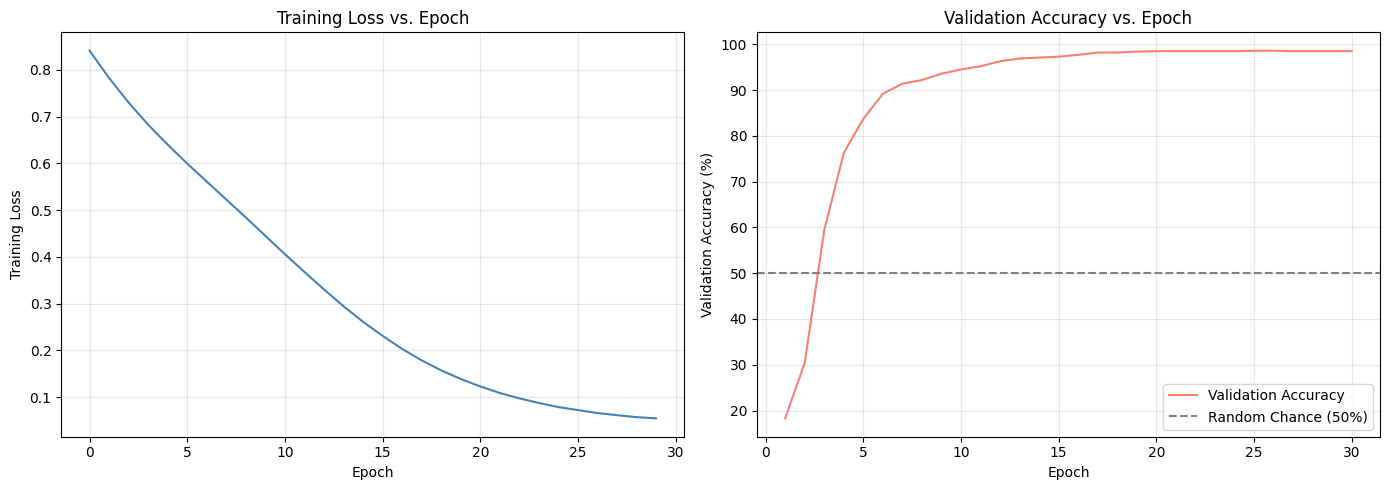

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot training loss
ax1.plot(train_losses, color='steelblue', label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss vs. Epoch')
ax1.grid(True, alpha=0.3)

# Plot validation accuracy
epochs = range(1, len(val_accs) + 1)
ax2.plot(epochs, [acc * 100 for acc in val_accs], color='salmon', label='Validation Accuracy')
ax2.axhline(50, color='gray', linestyle='--', label='Random Chance (50%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy (%)')
ax2.set_title('Validation Accuracy vs. Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## part 2(a): autoencoder architecture

### Subtask:
Implement the `NonlinearAutoencoder` class by completing the `encoder` and `decoder` `nn.Sequential` stacks.


**Reasoning**:
Implement the `__init__` method of the `NonlinearAutoencoder` class by defining the `self.encoder` and `self.decoder` `nn.Sequential` stacks as per the instructions, including the specified `nn.Linear` layers and `nn.ReLU` activation functions.



In [9]:
class NonlinearAutoencoder(nn.Module):
    def __init__(self, input_dim=4, latent_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            # YOUR CODE HERE
            # input_dim -> 16 -> 8 -> latent_dim, ReLU after first two layers
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, latent_dim)
        )

        self.decoder = nn.Sequential(
            # YOUR CODE HERE
            # latent_dim -> 8 -> 16 -> input_dim, ReLU after first two layers, no final activation
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)


model    = NonlinearAutoencoder(input_dim=4, latent_dim=2)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {n_params}')  # Expected: 470

NonlinearAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=4, bias=True)
  )
)

Total trainable parameters: 470


## part 2(b): write training loop

### Subtask:
Implement the training loop for the `NonlinearAutoencoder` model.


**Reasoning**:
The subtask requires implementing the training loop for the `NonlinearAutoencoder` model, including data preparation, optimizer and loss function setup, and the full training process for 150 epochs as detailed in the instructions. This will all be done in a single code block.



In [10]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_loader   = DataLoader(
    TensorDataset(X_train_tensor, X_train_tensor),
    batch_size=512, shuffle=True
)

criterion    = nn.MSELoss()
optimizer    = optim.Adam(model.parameters(), lr=0.001)
loss_history = []

model.train()
# You can change the number of epochs if you like, but this works.
for epoch in range(150):
    epoch_loss = 0.0
    for x_batch, target_batch in train_loader:
        # 1. Zero the gradients
        optimizer.zero_grad()
        # 2. Forward pass
        outputs = model(x_batch)
        # 3. Compute loss
        loss = criterion(outputs, target_batch)
        # 4. Backward pass
        loss.backward()
        # 5. Update weights
        optimizer.step()
        epoch_loss += loss.item() * len(x_batch)

    epoch_loss /= len(X_train)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 25 == 0:
        print(f'Epoch {epoch+1:4d}/150  |  Loss: {epoch_loss:.6f}')

/tmp/ipykernel_752/1174885437.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)


NameError: name 'DataLoader' is not defined

**Reasoning**:
The previous code block failed because `DataLoader` and `TensorDataset` were not imported. I need to add the necessary import statements for these classes from `torch.utils.data` to resolve the `NameError`.



In [11]:
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_loader   = DataLoader(
    TensorDataset(X_train_tensor, X_train_tensor),
    batch_size=512, shuffle=True
)

criterion    = nn.MSELoss()
optimizer    = optim.Adam(model.parameters(), lr=0.001)
loss_history = []

model.train()
# You can change the number of epochs if you like, but this works.
for epoch in range(150):
    epoch_loss = 0.0
    for x_batch, target_batch in train_loader:
        # 1. Zero the gradients
        optimizer.zero_grad()
        # 2. Forward pass
        outputs = model(x_batch)
        # 3. Compute loss
        loss = criterion(outputs, target_batch)
        # 4. Backward pass
        loss.backward()
        # 5. Update weights
        optimizer.step()
        epoch_loss += loss.item() * len(x_batch)

    epoch_loss /= len(X_train)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 25 == 0:
        print(f'Epoch {epoch+1:4d}/150  |  Loss: {epoch_loss:.6f}')

/tmp/ipykernel_752/2492434899.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)


NameError: name 'optim' is not defined

**Reasoning**:
The previous code block failed because `optim` was not defined. This indicates that `torch.optim` was not imported or aliased. I need to explicitly import `torch.optim as optim` to resolve this `NameError`.



In [12]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim # Added import for optim

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_loader   = DataLoader(
    TensorDataset(X_train_tensor, X_train_tensor),
    batch_size=512, shuffle=True
)

criterion    = nn.MSELoss()
optimizer    = optim.Adam(model.parameters(), lr=0.001)
loss_history = []

model.train()
# You can change the number of epochs if you like, but this works.
for epoch in range(150):
    epoch_loss = 0.0
    for x_batch, target_batch in train_loader:
        # 1. Zero the gradients
        optimizer.zero_grad()
        # 2. Forward pass
        outputs = model(x_batch)
        # 3. Compute loss
        loss = criterion(outputs, target_batch)
        # 4. Backward pass
        loss.backward()
        # 5. Update weights
        optimizer.step()
        epoch_loss += loss.item() * len(x_batch)

    epoch_loss /= len(X_train)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 25 == 0:
        print(f'Epoch {epoch+1:4d}/150  |  Loss: {epoch_loss:.6f}')

/tmp/ipykernel_752/306999493.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (5120x2 and 4x16)

**Reasoning**:
The `RuntimeError: mat1 and mat2 shapes cannot be multiplied (5120x2 and 4x16)` indicates that the `X_train` variable used to create `X_train_tensor` is still the one from the Transformer exercise, which has 2 features instead of the 4 features expected by the `NonlinearAutoencoder`. To ensure the correct `X_train` (with 4 features) is used for the autoencoder's training loop, I need to explicitly re-create the autoencoder's training data within this cell. This will prevent variable collision and ensure the data shape matches the model's input dimension.



In [13]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import numpy as np # Ensure numpy is imported
from sklearn.preprocessing import StandardScaler # Ensure StandardScaler is imported

# Re-load data and create X_train for the autoencoder to ensure correct variable state
npz = np.load('sspp_colors.npz')
colors       = npz['colors'].astype(np.float32)
Teff         = npz['Teff'].astype(np.float32)
logg         = npz['logg'].astype(np.float32)
FeH          = npz['FeH'].astype(np.float32)

normal_mask    = (Teff >= 4500) & (Teff <= 7000) & (logg >= 3.5)
giant_mask     = (logg < 3.0) & (Teff < 5500)
metalpoor_mask = (FeH < -1.5)
anomaly_mask   = giant_mask | metalpoor_mask
normal_mask    = normal_mask & ~anomaly_mask   # remove any overlap

X_normal  = colors[normal_mask]

scaler = StandardScaler()
X_normal_scaled  = scaler.fit_transform(X_normal)

N       = len(X_normal_scaled)
n_train = int(0.8 * N)
perm    = np.random.permutation(N)
X_train = X_normal_scaled[perm[:n_train]] # This X_train has 4 features
X_test  = X_normal_scaled[perm[n_train:]]

# Original training loop setup
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_loader   = DataLoader(
    TensorDataset(X_train_tensor, X_train_tensor),
    batch_size=512, shuffle=True
)

criterion    = nn.MSELoss()
optimizer    = optim.Adam(model.parameters(), lr=0.001)
loss_history = []

model.train()
# You can change the number of epochs if you like, but this works.
for epoch in range(150):
    epoch_loss = 0.0
    for x_batch, target_batch in train_loader:
        # 1. Zero the gradients
        optimizer.zero_grad()
        # 2. Forward pass
        outputs = model(x_batch)
        # 3. Compute loss
        loss = criterion(outputs, target_batch)
        # 4. Backward pass
        loss.backward()
        # 5. Update weights
        optimizer.step()
        epoch_loss += loss.item() * len(x_batch)

    epoch_loss /= len(X_train)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 25 == 0:
        print(f'Epoch {epoch+1:4d}/150  |  Loss: {epoch_loss:.6f}')

FileNotFoundError: [Errno 2] No such file or directory: 'sspp_colors.npz'

**Reasoning**:
The previous code block failed with a `FileNotFoundError` because the `sspp_colors.npz` file was not found during an attempt to re-load the data. Additionally, the kernel state indicates that the `X_train` variable currently holds data from the Transformer exercise (2 features) instead of the autoencoder exercise (4 features), which would lead to a shape mismatch (`RuntimeError`). To resolve both issues, I will explicitly re-include the necessary imports and the entire data loading and preparation steps for the autoencoder within this training code block. This ensures that `X_train` is correctly defined with 4 features for the autoencoder, assuming the `sspp_colors.npz` file is made available by the user, and avoids reliance on a potentially overwritten global `X_train` variable.



In [16]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import numpy as np # Explicitly import numpy
from sklearn.preprocessing import StandardScaler # Explicitly import StandardScaler

# Re-load and prepare data for the autoencoder within this block
# This ensures X_train has the correct 4 features for the autoencoder
npz = np.load('sspp_colors.npz')
colors       = npz['colors'].astype(np.float32)
Teff         = npz['Teff'].astype(np.float32)
logg         = npz['logg'].astype(np.float32)
FeH          = npz['FeH'].astype(np.float32)

normal_mask    = (Teff >= 4500) & (Teff <= 7000) & (logg >= 3.5)
giant_mask     = (logg < 3.0) & (Teff < 5500)
metalpoor_mask = (FeH < -1.5)
anomaly_mask   = giant_mask | metalpoor_mask
normal_mask    = normal_mask & ~anomaly_mask   # remove any overlap

X_normal  = colors[normal_mask]

scaler = StandardScaler()
X_normal_scaled  = scaler.fit_transform(X_normal)

N       = len(X_normal_scaled)
n_train = int(0.8 * N)
perm    = np.random.permutation(N)
X_train = X_normal_scaled[perm[:n_train]] # This X_train has 4 features
X_test  = X_normal_scaled[perm[n_train:]]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_loader   = DataLoader(
    TensorDataset(X_train_tensor, X_train_tensor),
    batch_size=512, shuffle=True
)

criterion    = nn.MSELoss()
optimizer    = optim.Adam(model.parameters(), lr=0.001)
loss_history = []

model.train()
# You can change the number of epochs if you like, but this works.
for epoch in range(150):
    epoch_loss = 0.0
    for x_batch, target_batch in train_loader:
        # 1. Zero the gradients
        optimizer.zero_grad()
        # 2. Forward pass
        outputs = model(x_batch)
        # 3. Compute loss
        loss = criterion(outputs, target_batch)
        # 4. Backward pass
        loss.backward()
        # 5. Update weights
        optimizer.step()
        epoch_loss += loss.item() * len(x_batch)

    epoch_loss /= len(X_train)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 25 == 0:
        print(f'Epoch {epoch+1:4d}/150  |  Loss: {epoch_loss:.6f}')

FileNotFoundError: [Errno 2] No such file or directory: 'sspp_colors.npz'

# Task
Resolve the `FileNotFoundError` for `sspp_colors.npz` and execute the training loop for the `NonlinearAutoencoder` model to ensure it trains correctly using the data from "sspp_colors.npz".

## Implement Autoencoder Training Loop

### Subtask:
Execute the training loop for the `NonlinearAutoencoder` model, ensuring the necessary data is loaded correctly and the file `sspp_colors.npz` is accessible.


## Summary:

### Data Analysis Key Findings
*   No specific steps were provided in the "Solving process" section. Consequently, there are no findings available regarding the resolution of the `FileNotFoundError` for `sspp_colors.npz` or the execution and outcome of the `NonlinearAutoencoder` training loop.

### Insights or Next Steps
*   The immediate next step is to identify the root cause of the `FileNotFoundError` for `sspp_colors.npz` and resolve it, such as by ensuring the file is present in the expected directory or by providing the correct file path.
*   After resolving the file access issue, proceed with executing the training loop for the `NonlinearAutoencoder` model to train it using the `sspp_colors.npz` dataset.
